# HD Integrated Visium Interactive Suite (HiVis) - basics

This Notebook describes the first steps in the analysis of VisiumHD experiment using HiVis.

To see a details explanation and parameters for each function, visit the [documentation](https://hivis.readthedocs.io/en/latest/).

The data in this tutorial is of mouse small intestine, available from [10X datasets](https://www.10xgenomics.com/datasets/visium-hd-cytassist-gene-expression-libraries-of-mouse-intestine), if you wish to follow along, download the following files:
* [Microscope image](https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_tissue_image.btf) (1.6 GB)
* [Binned outputs](https://cf.10xgenomics.com/samples/spatial-exp/3.0.0/Visium_HD_Mouse_Small_Intestine/Visium_HD_Mouse_Small_Intestine_binned_outputs.tar.gz) (6 GB). Extract the .gz and .tar files. In this tutorial we will use the **square_002um** folder since it has the highest precision, but the **square_008um** and **square_016um** can be used the same way.

In [1]:
import os
import sys
from HiVis import HiVis

sys.path.append(os.path.abspath(".."))

C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\_utils\__init__.py:35: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
C:\Users\royno.WISMAIN\AppData\Local\anaconda3\envs\hivis1\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## Import data
When creating a HiVis object, you need to specify the path of the data and image, and the name of the sample. Additionaly you can add any sample metadata as a dict, which is usefull when working with multiple samples. Specifying the organism is recommended (i.e human or mouse), since it allows case-sensitivity string correction and mitochondrial gene identification for QC.

During the first import, which can take few minutes, the image is cropped to the actual coordinates of the data. The cropped image is the one that should be used later, when working with QuPath.

[Loading images]
[Loading metadata]
[Loading data]


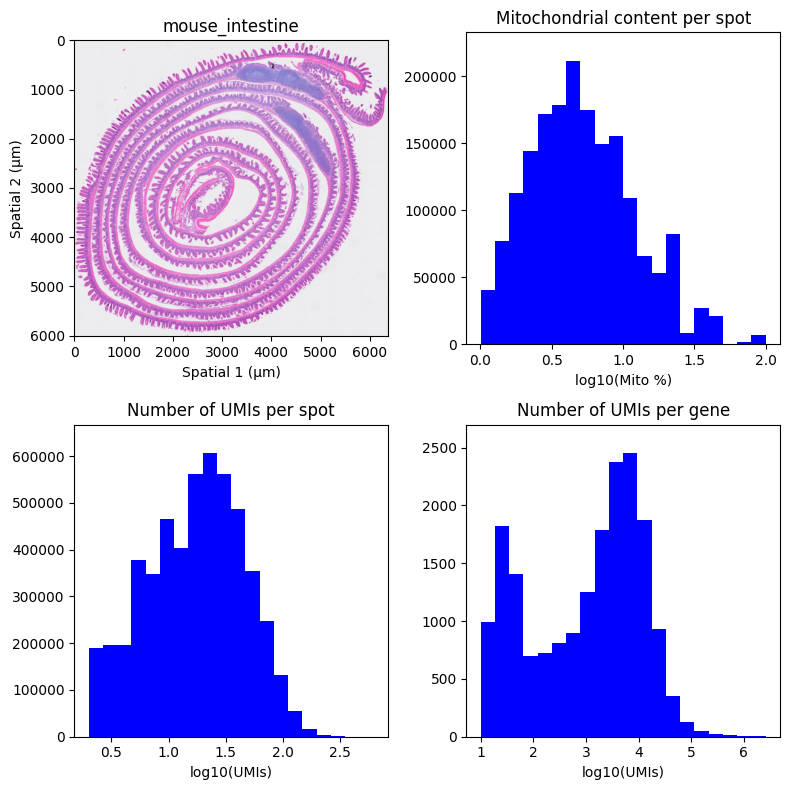

In [2]:
path_image_fullres = r"outs\Visium_HD_Mouse_Small_Intestine_tissue_image.btf"
path_input_data = r"outs\binned_outputs\square_002um"
path_output = r"output"
properties = {"organism":"mouse",
              "organ":"Small intestine",
              "cancer": False,
              "source":"10X"}
si = HiVis.new_visiumHD(path_image_fullres, 
               path_input_data, 
               path_output,
               name="mouse_intestine",  
               properties=properties) # There are also filtering options, see documentation

We now have a HiVis object, which stores the images, anndata and enables plotting and basic analysis

In [3]:
si 

# mouse_intestine #
	Organism: mouse
	Size: 5367189 x 18612

obs: in_tissue, array_row, array_col, pxl_row_in_fullres, pxl_col_in_fullres, pxl_col_in_lowres, pxl_row_in_lowres, pxl_col_in_highres, pxl_row_in_highres, um_x, um_y, nUMI, mito_sum, nUMI_log10, mito_percent_log10

var: gene_ids, feature_types, genome, nUMI_gene, nUMI_gene_log10

## HiVis attributes

There are attributes we can access in HiVis.

In [4]:
si.adata

AnnData object with n_obs × n_vars = 5367189 × 18612
    obs: 'in_tissue', 'array_row', 'array_col', 'pxl_row_in_fullres', 'pxl_col_in_fullres', 'pxl_col_in_lowres', 'pxl_row_in_lowres', 'pxl_col_in_highres', 'pxl_row_in_highres', 'um_x', 'um_y', 'nUMI', 'mito_sum', 'nUMI_log10', 'mito_percent_log10'
    var: 'gene_ids', 'feature_types', 'genome', 'nUMI_gene', 'nUMI_gene_log10'
    uns: 'spatial'
    obsm: 'spatial'

In [5]:
print(si.name)
print(si.image_fullres.shape) # Also image_highres, image_lowres
print(si.shape) # spots * genes
print(si.path_output)
print(si.properties)
print(si.json)

mouse_intestine
(21943, 23304, 3)
(5367189, 18612)
output
{'organism': 'mouse', 'organ': 'Small intestine', 'cancer': False, 'source': '10X'}
{'spot_diameter_fullres': 7.30563538369773, 'bin_size_um': 2.0, 'microns_per_pixel': 0.27376126715315274, 'regist_target_img_scalef': 0.25404352, 'tissue_lowres_scalef': 0.025404353, 'fiducial_diameter_fullres': 1205.4298383101254, 'tissue_hires_scalef': 0.25404352}


*****

Data can easily be acessed through the AnnData or directly

In [6]:
print("nUMI: " + str(si["nUMI"])) # obs
print("nUMI_gene: " + str(si["nUMI_gene_log10"])) # var
gene = "Apob"
print("Apob: " + str(si[gene])) # gene data

nUMI: [ 1. 13.  5. ... 16. 15. 29.]
nUMI_gene: [2.2227166 1.3222193 3.0195317 ... 4.1098824 5.3952827 3.8132472]
Apob: [0. 0. 0. ... 0. 0. 0.]


Similarly, we can easily add metadata

In [7]:
si["Apob_positive"] = si["Apob"] > 1
si["Apob_positive"]

array([False, False, False, ..., False, False, False], shape=(5367189,))

In [8]:
si["Mitochondrial_gene"] = si.adata.var_names.str.startswith("mt-")
si["Mitochondrial_gene"]

array([False, False, False, ...,  True,  True, False], shape=(18612,))

And delete metadata

In [9]:
del si["Mitochondrial_gene"]

## Subsetting the HiViz object
We can subset our object based on obs and/or var.

In this example we will subset only genes that are relatively highly expressed. 

The subsetting will create a new HiVis object.

In [10]:
high_expressed = si["nUMI_gene"] > 10000
high_umi = si["nUMI"] > 1
si_subset = si[high_umi, high_expressed]
si_subset.rename("highly_expressed_genes") # otherwise it will be called "subset"

We can also subset based on OBS, for example by x,y coordinates.

In [11]:
si_subset2 = si[((si["um_x"] < 400) & (si["um_y"] < 3600) & (si["um_y"] > 3200)),high_expressed]


Or just use the .crop() method

In [12]:
si_subset2 = si.crop(xlim=[0,400],ylim=[3200,3600])

If we look at basic Quality Control, we see that the image and data is cropped.

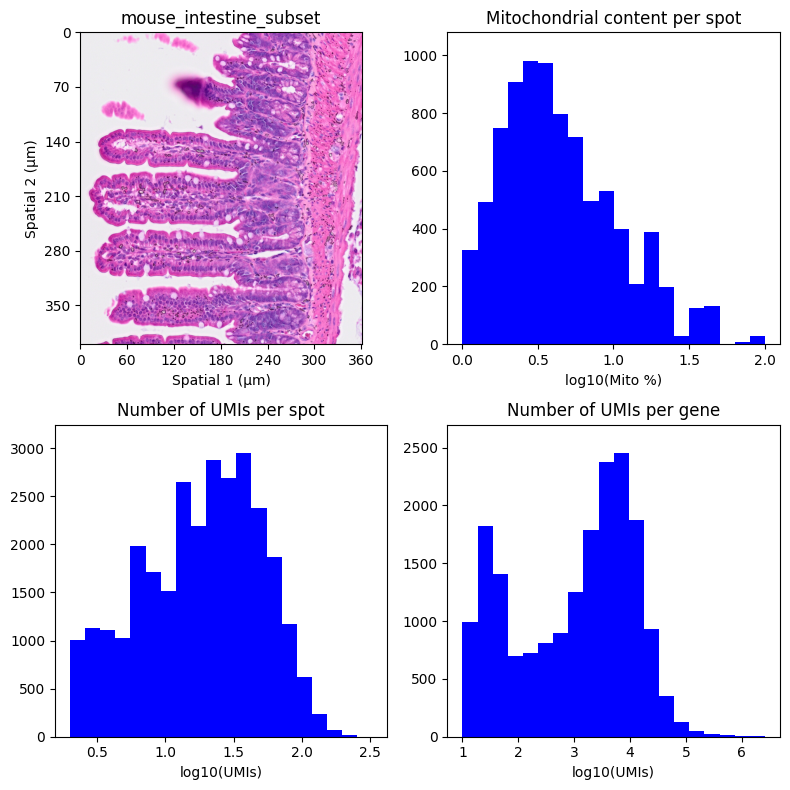

In [13]:
si_subset2.analysis.qc()

## copying and saving HiVis
We can create copies of HiVis objects (not linked to the original object in any way). 

In [14]:
si_copy = si_subset.copy(new_name="copy")
si_copy.name

'mouse_intestine_highly_expressed_genes_copy'

We can rename the object

In [15]:
si_subset.rename("mouse_intestine",full=True) # Full means we specify the whole name, not just adding to the existing
si_subset.name

'mouse_intestine'

To avoid running the analysis every time, you can save the HiVis object as a pickle file. It will be saved in HiVis.path_output.

The save will include all the Aggregations (which are covered in next notebooks)

In [16]:
path = si_subset.save()
path

SAVING [mouse_intestine]


'output/mouse_intestine.pkl'

To later load the object, we can simply run 

StopAsyncIteration: 

In [ ]:
si_subset = HiVis.load(path)

We can also export the anndata

In [ ]:
si_subset.export_h5()

And we can export the images, the json and the coordinates of spots. This is especially usefull for aggregating single cells, which will be covered in next notebook.

In [ ]:
files = si_subset.export_images()
_ = [print(getattr(x, 'shape', x)) for x in files]